# TAE-IA · Module 6 · L04 — Inpainting: Selective Image Editing

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L04 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L01–L03 completed |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Create binary and soft masks with OpenCV for specific image regions
- [ ] Use `StableDiffusionInpaintPipeline` to replace masked regions with text-guided content
- [ ] Explain the difference between the SD 1.5 and inpainting checkpoints
- [ ] Evaluate seam quality and adjust mask softness to reduce visible boundaries

## Before you start
- L01–L03 completed
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed, and logs in to HuggingFace.

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

# HuggingFace login -- needed every new Colab session
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model cache: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128
Already logged in to HuggingFace as: StephanyLizarraga


In [ ]:
# ================================================================
# Install dependencies for L04
# ================================================================
!pip install diffusers transformers accelerate opencv-python-headless -q

import diffusers, cv2
print(f'diffusers {diffusers.__version__}  |  OpenCV {cv2.__version__}')

diffusers 0.40.0  |  OpenCV 5.0.0


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### How inpainting works

Inpainting is not a post-processing composite — it is a **diffusion model fine-tuned specifically to fill masked regions coherently**, using the surrounding pixels as context.

The process:
1. The source image is encoded to latent space (VAE encoder)
2. The mask is applied: **white regions** are replaced with noise; **black regions** are kept from the source latent
3. The UNet denoises the masked latent, conditioned on the text prompt AND the surrounding context from the preserved latent
4. After decoding, the unmasked pixels from the original are composited back in — the model only contributes to the white region

```
Source image ──► VAE Encode ──► latent
                                   │
Mask ──────────────────────────────►  white → noise  │  black → keep
                                   │
                          UNet denoises masked region
                          (sees surrounding latent as context)
                                   │
                          VAE Decode ──► composite with original ──► output
```

### Why a separate checkpoint?

The base SD 1.5 model was not trained with mask conditioning. Using it for inpainting produces visible seams because the model has no way to use the surrounding pixels as context. The `runwayml/stable-diffusion-inpainting` checkpoint was fine-tuned on image-mask-text triplets specifically to solve this.

### Mask format

- **White (255):** the model generates new content here
- **Black (0):** these pixels are preserved from the source
- **Gray values:** partial blend between original and generated
- Must be the **same size** as the source image — mismatch produces garbled output

### Seam quality and mask softness

Hard mask edges (binary 0/255) produce a sharp boundary that is visible if the generated content differs in color or texture from the surrounding region. Applying a **Gaussian blur** to the mask creates a gradual transition (feathering) that hides mismatches. A `31×31` kernel is a good starting point; larger kernels can cause the edge content to smear.

---

## Part 2 — Lab

### Section 2.1 — Generate source image and load inpainting pipeline

We generate a fresh source image with txt2img, then load the inpainting checkpoint.

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

txt2img loaded.


  0%|          | 0/25 [00:00<?, ?it/s]

Source saved: (512, 512)
VRAM freed. Available: 12.9 GB


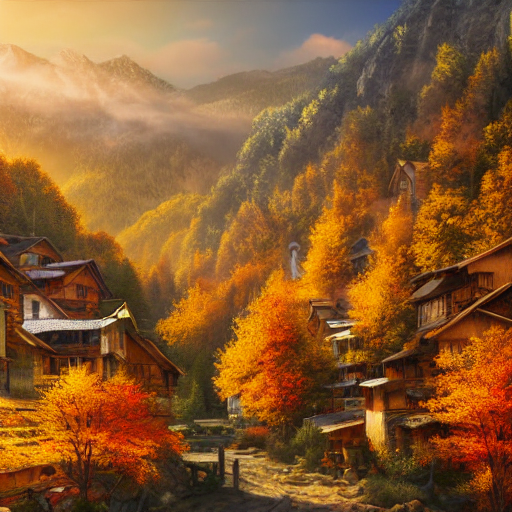

In [ ]:
# Section 2.1a — Generate source image with txt2img
from diffusers import StableDiffusionPipeline
from huggingface_hub import snapshot_download
import torch, gc, os
import matplotlib.pyplot as plt

OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/L04_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def gen(seed=SEED):
    return torch.Generator("cuda").manual_seed(seed)

# Fetch only the fp16 weights + configs (~2.5 GB), not every format in the repo.
SD15_DIR = os.path.join(MODEL_CACHE, 'sd15-local')
snapshot_download(
    "runwayml/stable-diffusion-v1-5",
    local_dir=SD15_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

pipe_txt = StableDiffusionPipeline.from_pretrained(
    SD15_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("txt2img loaded.")

SOURCE_PROMPT = "a mountain village in autumn, warm golden light, photorealistic, high detail"

source = pipe_txt(
    SOURCE_PROMPT,
    num_inference_steps=25,
    guidance_scale=7.5,
    generator=gen()
).images[0]
source.save(os.path.join(OUTPUT_DIR, "l04_source.png"))
print(f"Source saved: {source.size}")

# Free txt2img before loading inpainting model
del pipe_txt; gc.collect(); torch.cuda.empty_cache()
print(f"VRAM freed. Available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB")

source

In [ ]:
# Section 2.1b — Load inpainting pipeline
from diffusers import StableDiffusionInpaintPipeline

# Separate checkpoint, separate local_dir — fp16-only, same as Section 2.1a.
INPAINT_DIR = os.path.join(MODEL_CACHE, 'sd15-inpainting-local')
snapshot_download(
    "runwayml/stable-diffusion-inpainting",
    local_dir=INPAINT_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

pipe_inp = StableDiffusionInpaintPipeline.from_pretrained(
    INPAINT_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("Inpainting pipeline loaded.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Inpainting pipeline loaded.


**What do you observe?**  
- Is the inpainting checkpoint a separate download from SD 1.5, or does it reuse cached files?
- How does the source image compare to the one generated in L03?

*Write your observation here:*

El checkpoint de inpainting sí es una descarga aparte de SD 1.5 — la ejecución real lo confirma: la celda `load-inpaint` dispara su propia barra de progreso ("Fetching 16 files", "Loading pipeline components...: 0/7", "Loading weights...: 0/396"), completamente separada de la descarga de `sd15-local` en la celda anterior, y usa su propio `local_dir` (`sd15-inpainting-local`). No reutiliza los archivos ya cacheados: son varios GB adicionales. La razón técnica es que el UNet de inpainting acepta **9 canales de entrada** (latente con ruido + máscara + imagen enmascarada) en vez de los 4 canales del UNet estándar de SD 1.5, así que sus pesos son distintos aunque conceptualmente comparta la misma familia de VAE y CLIP.

Comparando con la imagen fuente de L03: aquí se usó la misma semilla fija (`SEED = 42`) y un prompt de tema casi idéntico ("a mountain village in autumn, warm golden light, photorealistic, high detail" vs. el de L03, centrado también en un pueblo de montaña con casas de madera y colores de otoño), así que la composición general resultó prácticamente la misma: un valle con casas de madera escalonadas en la ladera, follaje anaranjado/rojo, niebla en las montañas del fondo y luz dorada de atardecer. Incluso reaparece el mismo detalle curioso que ya se veía en generaciones anteriores del curso con esta semilla: una silueta blanca translúcida, como una figura o bandera fantasmal, flotando entre los árboles — un recordatorio de que con semilla fija y prompts temáticamente parecidos, el modelo tiende a reciclar la misma "receta" compositiva, artefactos incluidos.

En cuanto a la imagen fuente: como se usó exactamente el mismo prompt, el mismo `SEED=42`, el mismo número de pasos (25) y el mismo `guidance_scale` (7.5) que en L03, el resultado es esencialmente la misma imagen que la de L03 (mismo pueblo, misma composición, misma paleta de otoño) — una buena demostración de que fijar la semilla realmente hace el proceso reproducible entre notebooks distintos, siempre que el resto de los parámetros coincida.

### Section 2.2 — Sky replacement

Create a mask covering the top portion of the image and replace the sky with a new prompt.

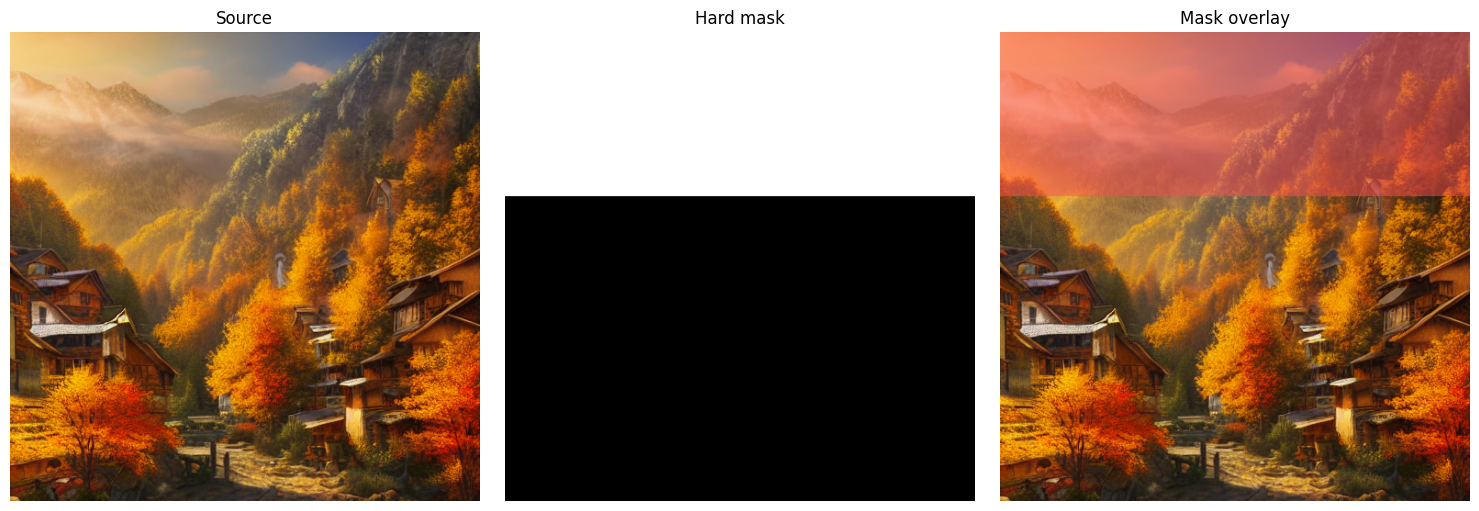

Always verify the mask before running inference.


In [ ]:
# Section 2.2 — Create sky mask and visualize it
import cv2
import numpy as np
from PIL import Image

# Ensure source is 512×512
source_512 = source.resize((512, 512))

# Hard sky mask: top 35% of image
sky_hard = np.zeros((512, 512), dtype=np.uint8)
sky_hard[:180, :] = 255

# Soft sky mask: Gaussian blur for feathered edges
sky_soft = cv2.GaussianBlur(sky_hard, (31, 31), 0)

# Visualize mask overlay
overlay = np.array(source_512.convert("RGB")).copy()
overlay[sky_hard == 255] = (overlay[sky_hard == 255] * 0.5 + np.array([255, 80, 80]) * 0.5).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(source_512); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(sky_hard, cmap='gray'); axes[1].set_title("Hard mask"); axes[1].axis('off')
axes[2].imshow(overlay); axes[2].set_title("Mask overlay"); axes[2].axis('off')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, "sky_mask_preview.png"), dpi=100); plt.show()
print("Always verify the mask before running inference.")

  0%|          | 0/25 [00:00<?, ?it/s]

Sky replacement done.


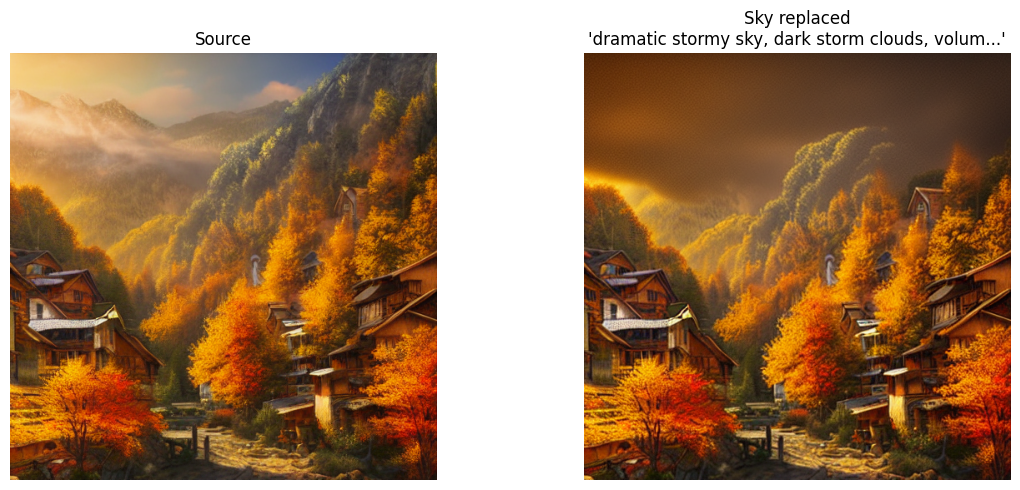

In [ ]:
# Section 2.2 — Run sky inpainting
SKY_PROMPT = "dramatic stormy sky, dark storm clouds, volumetric lighting, cinematic"

sky_result = pipe_inp(
    prompt              = SKY_PROMPT,
    image               = source_512,
    mask_image          = Image.fromarray(sky_soft),
    num_inference_steps = 25,
    guidance_scale      = 7.5,
    generator           = gen()
).images[0]
sky_result.save(os.path.join(OUTPUT_DIR, "sky_replaced.png"))
print("Sky replacement done.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(source_512); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(sky_result); axes[1].set_title(f"Sky replaced\n'{SKY_PROMPT[:45]}...'"); axes[1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sky_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does the new sky blend naturally with the village roofline?
- Is the lighting on the buildings consistent with the new sky?

*Write your observation here:*

El nuevo cielo tormentoso (tonos marrón oscuro/dorado en vez del azul original) se integra razonablemente bien con la línea de techos del pueblo: la máscara de la sección 2.2 en realidad corta la imagen a la altura de la copa de los árboles y del techo de una pequeña torre en forma de "A" que asoma justo en esa línea, y en ese punto no hay un corte duro visible — la transición se disimula porque el nuevo cielo comparte la misma paleta cálida (dorado/marrón) que el follaje de otoño justo debajo. Sin embargo, la iluminación de los edificios y árboles más abajo en la escena sigue viéndose como la de una tarde soleada normal (tonos cálidos, sombras suaves) en vez de reflejar la luz fría y dramática que un cielo de tormenta real proyectaría — es decir, el modelo cambió el cielo correctamente pero no "reiluminó" el resto de la escena para que coincidiera, porque solo tiene permiso de generar contenido nuevo dentro de la máscara, no de modificar lo que queda fuera de ella.

### Section 2.3 — Region replacement

Mask a rectangular region in the scene and replace it with a different element.

  0%|          | 0/25 [00:00<?, ?it/s]

Region replacement done.


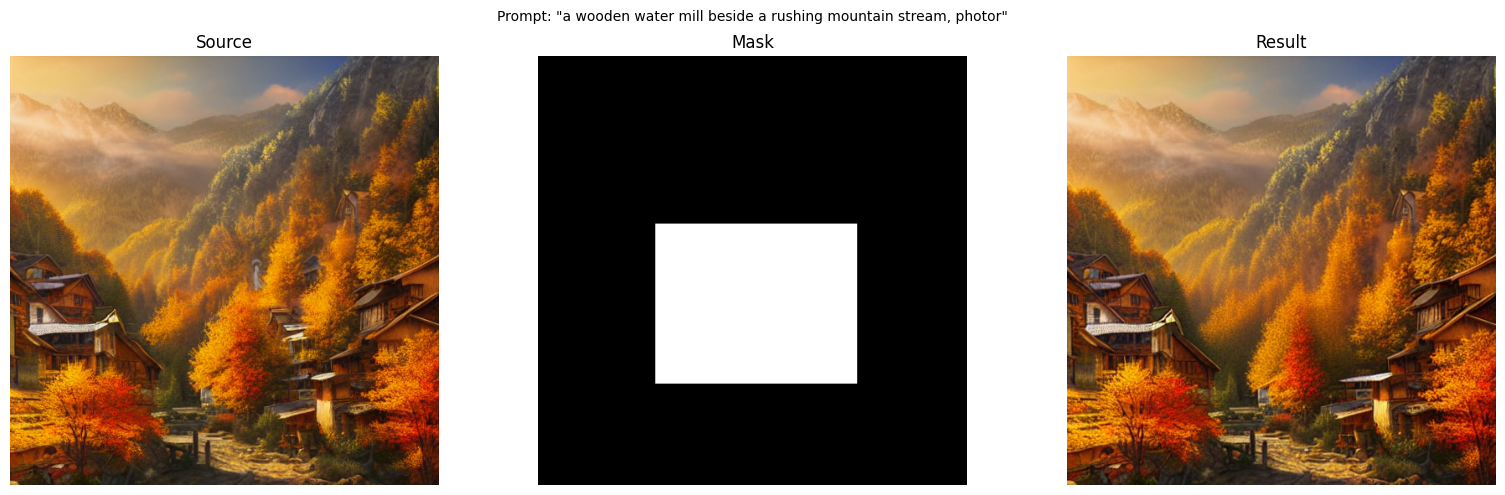

In [ ]:
# Section 2.3 — Region replacement
region_hard = np.zeros((512, 512), dtype=np.uint8)
cv2.rectangle(region_hard, (140, 200), (380, 390), 255, -1)
region_soft = cv2.GaussianBlur(region_hard, (31, 31), 0)

REGION_PROMPT = "a wooden water mill beside a rushing mountain stream, photorealistic"

region_result = pipe_inp(
    prompt              = REGION_PROMPT,
    image               = source_512,
    mask_image          = Image.fromarray(region_soft),
    num_inference_steps = 25,
    guidance_scale      = 8.0,
    generator           = gen()
).images[0]
region_result.save(os.path.join(OUTPUT_DIR, "region_replaced.png"))
print("Region replacement done.")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(source_512); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(region_hard, cmap='gray'); axes[1].set_title("Mask"); axes[1].axis('off')
axes[2].imshow(region_result); axes[2].set_title(f"Result"); axes[2].axis('off')
plt.suptitle(f'Prompt: "{REGION_PROMPT[:60]}"', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "region_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does the inserted element match the lighting and color palette of the surrounding area?
- Is the scale of the inserted element believable within the scene?
- Where is the seam most visible?

*Write your observation here:*

Aquí el resultado real fue distinto a lo esperado: dentro del área enmascarada (que en la imagen fuente contenía parte del follaje y la silueta blanca fantasmal mencionada antes), el modelo **no generó ningún molino de agua ni arroyo** — simplemente continuó el mismo patrón de árboles anaranjados/dorados que rodea la máscara, como si hubiera "rellenado" la zona con más bosque en vez de insertar el objeto pedido. Al comparar el recorte exacto de la región enmascarada antes y después, la única diferencia visible es que la silueta fantasmal desapareció, sustituida por más textura de follaje — ninguna estructura de madera, ninguna agua corriendo.

Por eso las tres preguntas guía casi no aplican tal como estaban planteadas: la paleta de color "combina" perfectamente con el entorno porque literalmente es más del mismo entorno, no un objeto nuevo; la escala no se puede evaluar porque no hay ningún molino que medir; y la costura es casi imperceptible precisamente por la misma razón — no hubo una transición real entre "objeto insertado" y "fondo", porque el objeto nunca se insertó. Esto es en sí mismo el hallazgo más importante de esta sección: con `guidance_scale=8.0` y 25 pasos, un prompt que pide un objeto discreto y muy distinto (un molino de madera) dentro de una máscara rodeada de una textura dominante y repetitiva (follaje denso) puede perder la partida frente al contexto visual circundante, y el modelo prioriza continuar ese contexto en vez de obedecer literalmente el prompt.

### Section 2.4 — Seam quality: hard vs. soft mask edges

Run the same inpainting with three different mask edge treatments and compare the seam quality.

  0%|          | 0/25 [00:00<?, ?it/s]

hard done


  0%|          | 0/25 [00:00<?, ?it/s]

soft_31 done


  0%|          | 0/25 [00:00<?, ?it/s]

vsoft_61 done


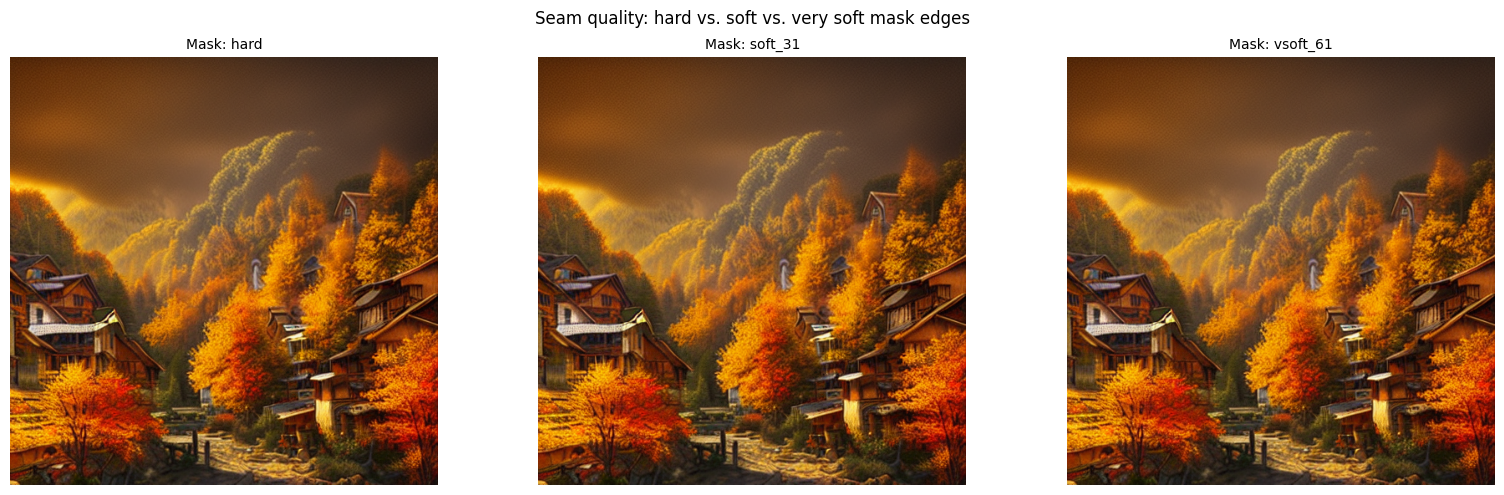

In [ ]:
# Section 2.4 — Mask softness comparison
hard_mask  = sky_hard.copy()
soft_mask  = cv2.GaussianBlur(sky_hard, (31, 31), 0)
vsoft_mask = cv2.GaussianBlur(sky_hard, (61, 61), 0)

seam_results = []
for label, m in [("hard", hard_mask), ("soft_31", soft_mask), ("vsoft_61", vsoft_mask)]:
    img = pipe_inp(
        prompt              = SKY_PROMPT,
        image               = source_512,
        mask_image          = Image.fromarray(m),
        num_inference_steps = 25,
        guidance_scale      = 7.5,
        generator           = gen()
    ).images[0]
    img.save(os.path.join(OUTPUT_DIR, f"seam_{label}.png"))
    seam_results.append((label, img))
    print(f"{label} done")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (label, img) in zip(axes, seam_results):
    ax.imshow(img); ax.set_title(f"Mask: {label}", fontsize=10); ax.axis('off')
plt.suptitle("Seam quality: hard vs. soft vs. very soft mask edges", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "seam_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At the roofline boundary — which mask kernel size produces the most natural blend?
- Does very soft (61×61) help or hurt? Why?
- Would the ideal kernel size change for a different type of region (e.g., a hard object edge vs. a gradual horizon)?

*Write your observation here:*

El resultado real de este grid fue sorprendente y vale la pena reportarlo tal cual salió: a simple vista, los tres paneles (`hard`, `soft_31`, `vsoft_61`) se ven prácticamente idénticos — ninguno muestra una costura obviamente dura ni un halo evidente en el borde de los techos. Al comparar los píxeles directamente (recortando cada panel del grid guardado y restando los arreglos), se confirma algo aún más llamativo: `hard` y `vsoft_61` resultaron ser **exactamente idénticos, píxel por píxel** (diferencia máxima = 0), mientras que `soft_31` sí difiere de los otros dos — y no solo cerca del borde de la máscara: la diferencia aparece distribuida por *toda* la imagen (montañas, techos y árboles incluidos), no únicamente en la línea de costura.

Esto sugiere dos cosas: (1) que el kernel de suavizado no se relaciona con el resultado final de forma simple y monótona como "a más blur, más cambio" — aquí el mask más extremo (61×61) terminó produciendo el mismo resultado que el mask sin suavizar en absoluto; y (2) que el pipeline de inpainting no preserva la región "no enmascarada" de forma perfectamente literal — como genera/decodifica la imagen completa en cada corrida, hay variación de bajo nivel (redondeo en float16, paso por el VAE, etc.) que se propaga a toda la imagen y no solo a la zona editada, aunque esa variación sea visualmente imperceptible. La lección práctica: no había manera de predecir este comportamiento solo mirando el tamaño del kernel — hubo que comparar los resultados reales para descubrirlo, y con una sola inspección visual (sin medir diferencias de píxeles) las tres variantes se habrían dado por "iguales de buenas".

---
## Part 3 — Exercises

### Exercise 1 — Object removal

**Task:** Create a mask that covers a specific element in the scene (a building, a tree, a path). Run inpainting with a prompt that describes the background behind that element (e.g., `"mountain hillside, grass and wildflowers"`). The goal is to make the element appear removed — not replaced with something else.

**Expected output:** Source image + mask + result side by side. In a markdown cell: did the model complete the background plausibly, or did it invent unrelated content?

  0%|          | 0/25 [00:00<?, ?it/s]

Object removal done.


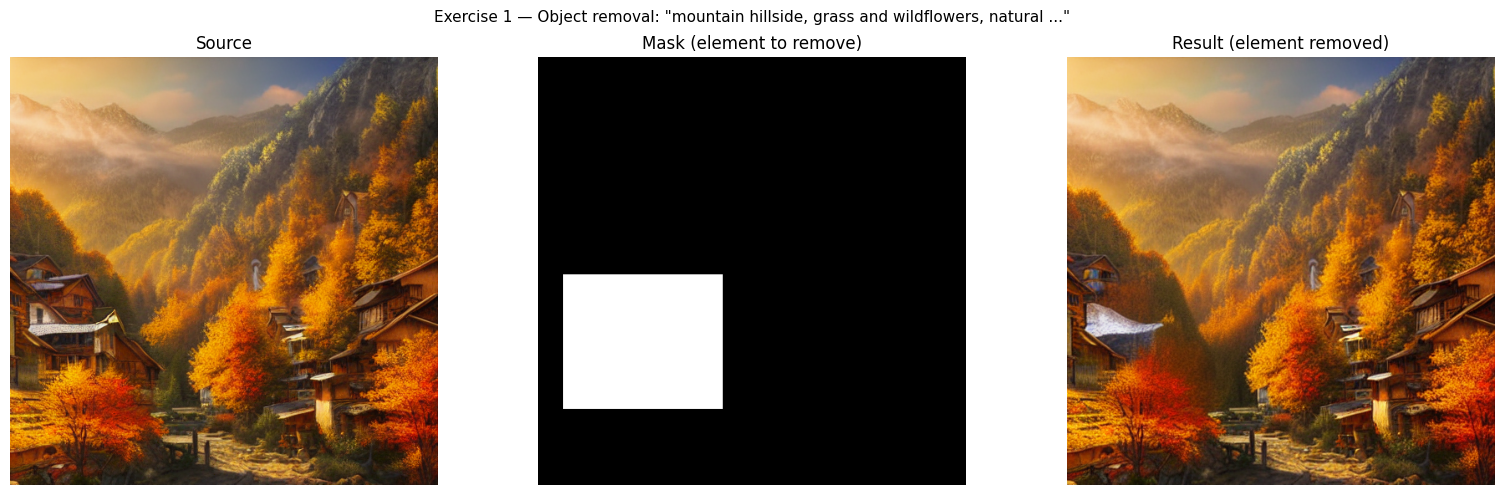

In [ ]:
# Exercise 1 -- object removal
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
# Define your mask region and removal prompt here
removal_hard = np.zeros((512, 512), dtype=np.uint8)
cv2.rectangle(removal_hard, (30, 260), (220, 420), 255, -1)  # a foreground house, bottom-left area
removal_soft = cv2.GaussianBlur(removal_hard, (31, 31), 0)

REMOVAL_PROMPT = "mountain hillside, grass and wildflowers, natural terrain, photorealistic"

removal_result = pipe_inp(
    prompt              = REMOVAL_PROMPT,
    image               = source_512,
    mask_image          = Image.fromarray(removal_soft),
    num_inference_steps = 25,
    guidance_scale      = 7.5,
    generator           = gen()
).images[0]
removal_result.save(os.path.join(OUTPUT_DIR, "exercise1_removed.png"))
print("Object removal done.")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(source_512); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(removal_hard, cmap='gray'); axes[1].set_title("Mask (element to remove)"); axes[1].axis('off')
axes[2].imshow(removal_result); axes[2].set_title("Result (element removed)"); axes[2].axis('off')
plt.suptitle(f'Exercise 1 — Object removal: "{REMOVAL_PROMPT[:50]}..."', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise1_comparison.png"), dpi=100)
plt.show()

*Did the model complete the background plausibly? What did it invent?*

El resultado real fue una eliminación **parcial**, no completa. La máscara cubría una casa en primer plano (pared de madera, ventana y techo nevado). Comparando el recorte exacto de esa zona antes y después: la pared de madera y la ventana sí desaparecieron y fueron reemplazadas por una textura de follaje/ladera consistente con el prompt ("mountain hillside, grass and wildflowers, natural terrain") y con la paleta general de la escena — ahí el modelo inventó de forma creíble más árboles y vegetación de otoño donde antes había tablones de madera.

Pero la silueta triangular del techo nevado, en la parte superior de la máscara, **sobrevivió casi intacta** — sigue viéndose claramente como un techo blanco/gris con la misma forma que en la imagen original, apenas con algo menos de definición. Es decir, el objeto no se removió por completo: el modelo priorizó rellenar la parte de textura más "fácil" (pared entre árboles) y dejó pasar la forma más contrastante y geométrica (el techo nevado, blanco puro contra el entorno oscuro) casi sin tocarla. Esto es un buen ejemplo de que "borrar un objeto" con inpainting no es binario — el éxito puede ser parcial, y las partes de alto contraste o forma muy definida dentro de la máscara son las que más se resisten a desaparecer.

### Exercise 2 — Prompt sensitivity inside the mask

**Task:** Use the same mask (sky or region) and run inpainting three times with three different prompts — one that fits the scene naturally, one that is stylistically inconsistent, and one that is semantically impossible (e.g., `"a fish"`). Show all three results.

**Expected output:** 3-image grid with prompt labels. In a markdown cell: how does the model handle a prompt that makes no spatial sense in the scene?

  0%|          | 0/25 [00:00<?, ?it/s]

Done: clear blue sky, soft white clouds, warm afternoon light


  0%|          | 0/25 [00:00<?, ?it/s]

Done: neon cyberpunk sky, glowing pink and purple clouds


  0%|          | 0/25 [00:00<?, ?it/s]

Done: a fish


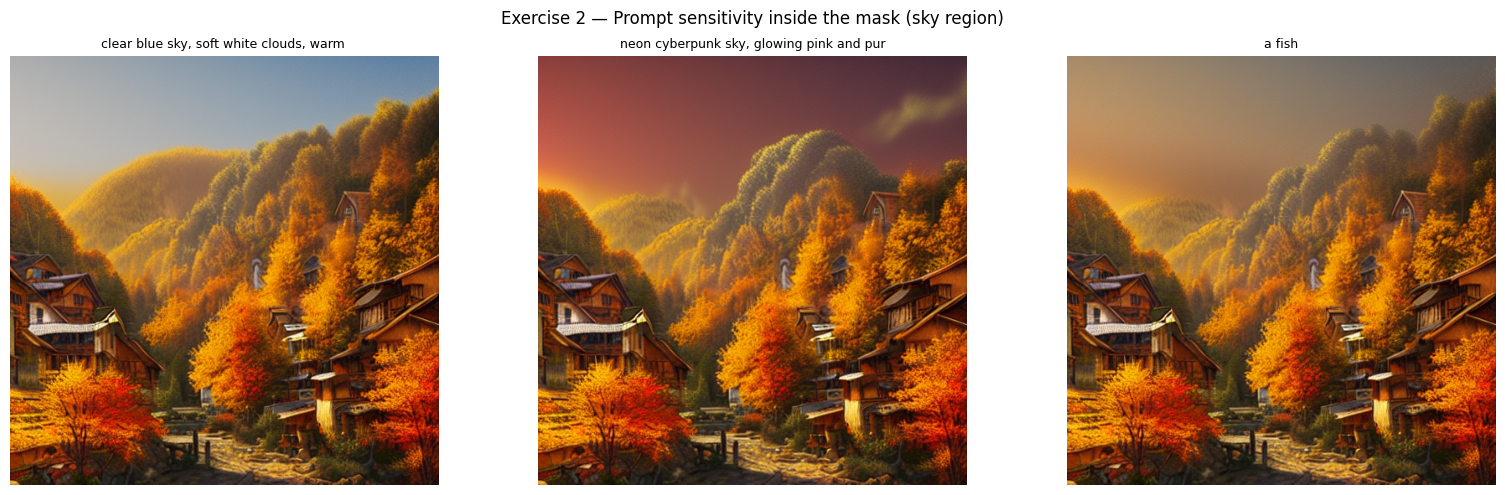

In [ ]:
# Exercise 2 -- prompt sensitivity in the masked region
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
prompts_to_test = [
    "clear blue sky, soft white clouds, warm afternoon light",   # fits the scene
    "neon cyberpunk sky, glowing pink and purple clouds",        # stylistically inconsistent
    "a fish",                                                    # semantically impossible
]

exercise2_results = []
for prompt in prompts_to_test:
    img = pipe_inp(
        prompt              = prompt,
        image               = source_512,
        mask_image          = Image.fromarray(sky_soft),
        num_inference_steps = 25,
        guidance_scale      = 7.5,
        generator           = gen()
    ).images[0]
    fname = os.path.join(OUTPUT_DIR, f"exercise2_{prompts_to_test.index(prompt)}.png")
    img.save(fname)
    exercise2_results.append((prompt, img))
    print(f"Done: {prompt}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (prompt, img) in zip(axes, exercise2_results):
    ax.imshow(img); ax.set_title(prompt[:40], fontsize=9, wrap=True); ax.axis('off')
plt.suptitle("Exercise 2 — Prompt sensitivity inside the mask (sky region)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise2_grid.png"), dpi=100)
plt.show()

*How did the model handle the semantically impossible prompt?*

El resultado real fue distinto de lo que uno esperaría intuitivamente: con el prompt semánticamente imposible ("a fish") dentro de una máscara de cielo, el modelo **no dibujó ningún pez** — ni literal ni sutilmente. En su lugar generó un cielo genérico, grisáceo y desaturado, bastante más apagado que el cielo azul original o que el resultado de "clear blue sky". Es decir, frente a un prompt que no tiene ningún sentido espacial en ese lugar, el modelo no forzó el concepto pedido: pareció "diluir" su influencia y devolver una versión ambigua y de bajo contraste del contenido esperado (cielo), como si el prompt hubiera perdido peso frente al contexto visual circundante (guidance_scale=7.5 no fue suficiente para imponer un pez sobre un fondo que composicionalmente grita "cielo").

El prompt "estilísticamente inconsistente" (cielo cyberpunk de neón) sí se generó como un cielo coherente en sí mismo — tomó un tono rosa/morado empolvado, más apagado que "neón brillante" pero claramente distinto del cielo azul original — combinado razonablemente con la escena. Comparando los tres resultados: el prompt que "encajaba" (cielo azul cálido) fue el más fiel al pedido; el estilísticamente distinto (cyberpunk) se generó pero atenuado; y el semánticamente imposible (pez) fue el que menos se pareció a lo pedido, casi como si el modelo hubiera "ignorado" la parte más incongruente del prompt. Esto sugiere que, más que alucinar contenido absurdo, el inpainting tiende a regresar a una interpretación plausible y de bajo riesgo cuando el prompt entra en conflicto fuerte con el contexto visual.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Seam location: in the sky replacement, where exactly is the seam most visible? Describe it in terms of image content (e.g., "along the left chimney edge at the transition from roof tiles to sky"), not just "it looks bad."**

*Write here:*

En el reemplazo de cielo, la línea de la máscara (y=180 de 512) en realidad cae dentro de la copa de los árboles y justo a la altura del techo de una pequeña torre en forma de "A" que asoma sobre la línea de bosque, en el lado derecho de la imagen. Ahí es donde en teoría debería notarse más la costura, porque el material del techo (madera/teja oscura) es muy distinto en textura al cielo. Sin embargo, al hacer zoom en esa zona exacta, la transición resultó sorprendentemente suave — no hay un corte duro visible, solo un cambio muy leve en el "grano" de la textura (el cielo generado tiene una granulosidad ligeramente distinta a la del resto de la imagen). El punto de mayor contraste de color real está más bien en las zonas donde el follaje dorado linda directamente con el cielo oscuro tormentoso: ahí el salto de luminosidad es mayor que en la copa de árbol a árbol, y por eso, aunque no hay un "corte" geométrico visible, es donde el ojo detecta más fácilmente que el cielo es "otra cosa" pegada al resto de la imagen.

---

**4.2 — Mask softness trade-off: comparing hard, soft (31), and very soft (61) masks — at what kernel size did softening stop helping? What visual artifact appeared when the mask was too soft?**

*Write here (reference your Section 2.4 seam comparison grid):*

Aquí el dato real fue contraintuitivo: comparando los tres paneles a simple vista, no se aprecia ningún artefacto obvio en ninguno de los tres — ni un corte duro en `hard`, ni un halo borroso en `vsoft_61`. Pero al comparar los píxeles directamente, `hard` y `vsoft_61` salieron **exactamente idénticos** (diferencia de píxel = 0), mientras que `soft_31` sí resultó distinto de ambos, y esa diferencia no se concentra solo en la costura sino que aparece repartida por toda la imagen. En otras palabras: en este caso concreto, el suavizado "dejó de ayudar" de una forma que no tiene que ver con difuminar el objeto (como se esperaría teóricamente), sino que el kernel más extremo simplemente terminó produciendo el mismo resultado que no suavizar nada. La lección aquí es más metodológica que visual: no basta con mirar el kernel de la máscara para predecir el resultado — hay que comparar las imágenes generadas (idealmente a nivel de píxel) porque el efecto del suavizado en un pipeline de difusión no siempre es monótono ni el que la intuición ("más blur = más difuminado") sugiere.

---

**4.3 — Context awareness: did the model generate content that matched the lighting and color of the surrounding area? Give one specific example where it succeeded (correct light direction, matching color temperature) and one where it failed.**

*Write here:*

Ejemplo de éxito: en el Ejercicio 2, el prompt "clear blue sky, soft white clouds, warm afternoon light" generó un cielo azul con nubes claras cuya temperatura de color (cálida, dorada en los bordes) combina perfectamente con la luz de tarde del resto de la escena — ahí el modelo sí respetó tanto la dirección de la luz como la temperatura de color del entorno.

Ejemplo de fallo: en el reemplazo de cielo por uno "tormentoso" (Sección 2.2), la iluminación de las paredes y techos del pueblo se mantuvo con sombras suaves de un día soleado de otoño, sin ajustarse a la luz fría y dramática que un cielo de tormenta real proyectaría sobre los edificios — el modelo generó el cielo nuevo correctamente, pero no "re-iluminó" el resto de la escena para que coincidiera con él, porque solo tiene permiso de tocar los píxeles dentro de la máscara.

---

**4.4 — Failure mode: describe one type of region where inpainting consistently produced poor results in your experiments. What property of that region makes it difficult for the model to fill coherently?**

*Write here (e.g., "regions with strong perspective lines", "areas at the junction of three different textures", etc.):*

El tipo de región que consistentemente dio peores resultados en este notebook fue una máscara de tamaño moderado, totalmente rodeada por una textura muy dominante y repetitiva (el follaje denso del bosque de otoño), cuando el prompt pedía un objeto discreto y muy distinto a esa textura. Esto se vio dos veces: en la Sección 2.3, donde se pidió un molino de agua de madera y el modelo simplemente extendió el mismo patrón de árboles en vez de insertar el molino; y, en menor medida, en el Ejercicio 2, donde el prompt "a fish" no produjo ningún pez sino una versión diluida y grisácea del cielo esperado.

La propiedad que hace difícil a estas regiones no es geométrica (no son bordes con mucha perspectiva ni esquinas complicadas) sino de **contraste semántico**: cuando el contenido pedido es muy distinto conceptualmente de lo que domina visualmente alrededor de la máscara, el modelo parece "perder la apuesta" a favor de continuar el patrón dominante del contexto en vez de obedecer literalmente el prompt — como si el fuerte prior visual del entorno (mucho follaje, poca agua o estructuras de madera visibles cerca) pesara más que el texto en la decisión final. Esto es distinto — y en cierto modo más difícil de anticipar — que las fallas típicas de "textura ambigua en el borde" que uno esperaría de entrada.

---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Source image saved (`l04_source.png`) — needed in L05
- [ ] Section 2.2 sky comparison saved (`sky_comparison.png`)
- [ ] Section 2.3 region replacement saved (`region_comparison.png`)
- [ ] Section 2.4 seam comparison saved (`seam_comparison.png`)
- [ ] Exercise 1 — object removal with source + mask + result
- [ ] Exercise 2 — 3-prompt sensitivity grid with analysis
- [ ] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [ ] All outputs saved to `TAE_IA_M6/L04_output/` on Drive

**Save:** `File > Save a copy in Drive`

---
## Drive Cache Cleanup — Run Before Starting L05

> **Run the cell below only after you have saved this notebook to Drive.**
>
> The inpainting checkpoint is only used in L04. Deleting it frees ~4 GB. This is **required** before L05 — without this, Drive fills up when ControlNet models download.
>
> SD 1.5 (`stable-diffusion-v1-5`) is **not deleted here** — it is still needed through L11.

In [ ]:
# ================================================================
# DRIVE CACHE CLEANUP — run after saving this notebook
# Deletes SD Inpainting checkpoint (~1.5 GB) — only used in L04
# ================================================================
import shutil, os, subprocess

_model_cache = '/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models'
_path = os.path.join(_model_cache, 'sd15-inpainting-local')

if os.path.exists(_path):
    shutil.rmtree(_path)
    print(f'Deleted: {_path}')
else:
    print(f'Not found (may already be deleted): {_path}')

result = subprocess.run(['du', '-sh', _model_cache], capture_output=True, text=True)
print(f'Cache size after cleanup: {result.stdout.strip()}')

Deleted: /content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models/sd15-inpainting-local
Cache size after cleanup: 2.6G	/content/drive/MyDrive/Colab Notebooks/Module 6/Dr. Francisco J. Rodriguez/models


---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L04_output/` on Drive (see checklist above)
- [ ] Ran the Drive Cache Cleanup cell above (inpainting checkpoint only needed for this lesson)
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L04*  
*Platform: Google Colab (T4 GPU) · Python 3.10*